# ME 3300 Lab 04 — Solution Notebook
**Signal Generation, Sampling, and Aliasing**

Instructor solution. Acquisition cells (dwfpy) are guarded by
`ADS_CONNECTED = False` so the notebook runs end-to-end against the synthetic
TA dataset in `../Data/` (from `generate_synthetic_data.py`). Set the flag
True at the bench to exercise the hardware path.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import date

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'DejaVu Serif']
plt.rcParams['font.size'] = 10

ADS_CONNECTED = False  # True only at the bench with hardware attached
today = date.today().strftime('%b %d, %Y')

## Part-3 — Scripted DC setpoints and the instrument comparison (hardware path)

The script sets W1 to each DC level, waits while the student reads the
handheld DMM (typed in via `input()`), then acquires and averages 2 s on
Channel 1. Runs only with hardware; otherwise the synthetic table in
`../Data/Static_Comparison.csv` is used.

In [2]:
if ADS_CONNECTED:
    import dwfpy as dwf

    set_points   = np.arange(0.0, 5.5, 1.0)   # 0, 1, 2, 3, 4, 5 V
    dmm_readings = []                          # typed in from the handheld DMM
    ads_means    = []                          # computed from the ADS capture

    fs, duration = 1000, 2.0
    n = int(fs * duration)

    with dwf.Device() as device:
        wavegen = device.analog_output         # the Wavegen instrument
        scope   = device.analog_input
        scope['ch1'].setup(range=5.0)

        for v_set in set_points:
            wavegen['ch1'].setup('dc', offset=v_set, start=True)   # W1 = v_set

            reading = float(input(f"W1 = {v_set:.1f} V. Type the DMM reading (V): "))
            dmm_readings.append(reading)

            scope.single(sample_rate=fs, buffer_size=n, configure=True, start=True)
            volts = scope['ch1'].get_data()
            ads_means.append(volts.mean())
            print(f"  DMM {reading:.3f} V | ADS mean {ads_means[-1]:.6f} V")

    np.savetxt('../Data/Static_Comparison.csv',
               np.column_stack([set_points, dmm_readings, ads_means]),
               header='set_V,dmm_V,ads_V', delimiter=',')

## Part-3 analysis — static error plot

Errors are (measured − set); both instruments on one figure, in mV.

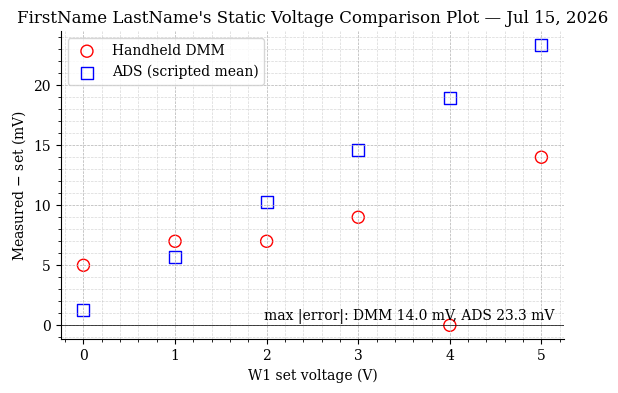

In [3]:
data = np.loadtxt('../Data/Static_Comparison.csv', delimiter=',', comments='#')
v_set, v_dmm, v_ads = data[:, 0], data[:, 1], data[:, 2]

err_dmm = (v_dmm - v_set) * 1000        # error in mV
err_ads = (v_ads - v_set) * 1000

fig, ax = plt.subplots(figsize=(6.5, 4.0))
fig.patch.set_facecolor('white')

ax.scatter(v_set, err_dmm, s=75, facecolors='none', edgecolors='red',
           label='Handheld DMM')
ax.scatter(v_set, err_ads, s=75, marker='s', facecolors='none',
           edgecolors='blue', label='ADS (scripted mean)')
ax.axhline(0, color='black', linewidth=0.5)

ax.set_xlabel('W1 set voltage (V)')
ax.set_ylabel('Measured $-$ set (mV)')
ax.set_title(f"FirstName LastName's Static Voltage Comparison Plot — {today}")
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.5)
ax.minorticks_on()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper left')

ax.text(0.98, 0.05,
        f"max |error|: DMM {np.max(np.abs(err_dmm)):.1f} mV, "
        f"ADS {np.max(np.abs(err_ads)):.1f} mV",
        transform=ax.transAxes, ha='right', va='bottom')

fig.savefig('../Figures/FirstName_LastName_Lab04_StaticError.png',
            dpi=600, bbox_inches='tight')
fig.savefig('../Figures/FirstName_LastName_Lab04_StaticError.pdf',
            dpi=600, bbox_inches='tight')
plt.show()

## Part-4 — predicted apparent frequencies (folding formula, Eq. 3)

In [4]:
fs  = 1000               # sample rate (Hz), fixed for the whole sweep
f_N = fs / 2             # Nyquist frequency (Hz)
f_signals = [100, 450, 500, 550, 1125]   # 0.2, 0.9, 1.0, 1.1, 2.25 x f_N

for f_sig in f_signals:
    f_app = abs(f_sig - round(f_sig / fs) * fs)     # folding formula
    print(f"f_signal = {f_sig:5d} Hz -> predicted apparent frequency = {f_app:.0f} Hz")

f_signal =   100 Hz -> predicted apparent frequency = 100 Hz
f_signal =   450 Hz -> predicted apparent frequency = 450 Hz
f_signal =   500 Hz -> predicted apparent frequency = 500 Hz
f_signal =   550 Hz -> predicted apparent frequency = 450 Hz
f_signal =  1125 Hz -> predicted apparent frequency = 125 Hz


## Part-4 — the aliasing sweep (hardware path)

One script generates each test signal on W1 and captures it on Channel 1 at
the fixed 1000 Hz sample rate — signal generator and DAQ in the same
`with` block.

In [5]:
if ADS_CONNECTED:
    import dwfpy as dwf
    import time

    duration = 1.0
    n = int(fs * duration)

    with dwf.Device() as device:
        wavegen = device.analog_output
        scope   = device.analog_input
        scope['ch1'].setup(range=5.0)

        for f_sig in f_signals:
            wavegen['ch1'].setup('sine', frequency=f_sig, amplitude=2.0,
                                 offset=2.5, start=True)
            time.sleep(0.2)                      # let the new output settle

            scope.single(sample_rate=fs, buffer_size=n, configure=True, start=True)
            volts  = scope['ch1'].get_data()
            time_s = np.arange(n) / fs           # sample times: 0, 1/fs, 2/fs, ...

            np.savetxt(f'../Data/Alias_{f_sig}Hz.csv',
                       np.column_stack([time_s, volts]),
                       header='Time (s),Channel 1 (V)', delimiter=',')
            print(f"saved Alias_{f_sig}Hz.csv")

## Part-4 analysis — five-panel aliasing figure

`observed` values are read off each panel by hand (peak-to-peak spacing);
they are the student's own judgment call, entered as strings below.

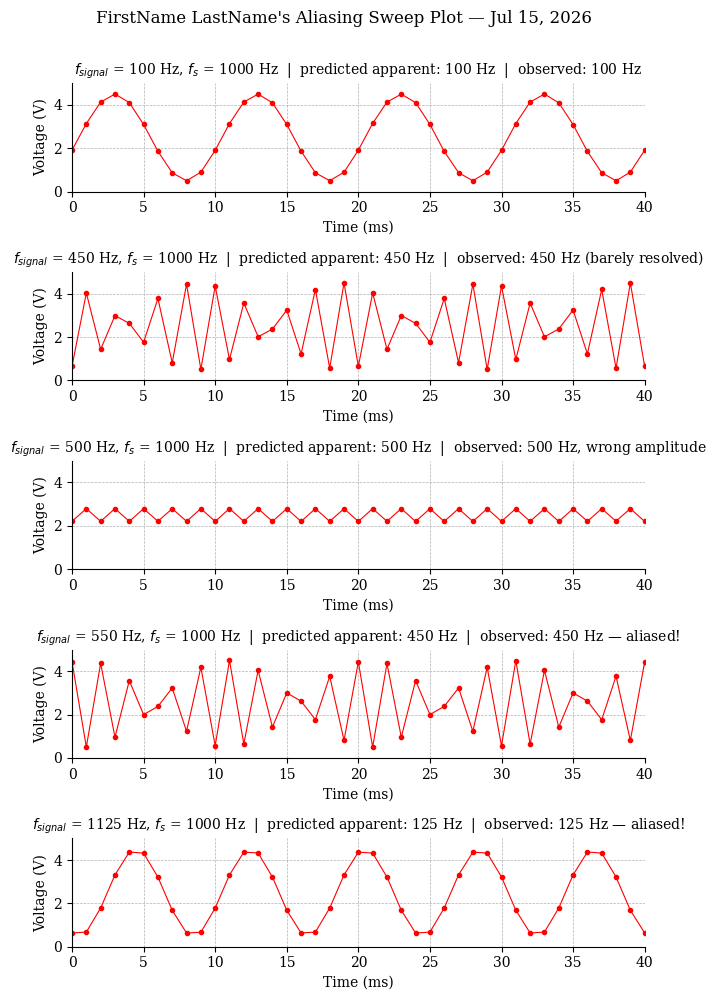

In [6]:
observed = ['100 Hz',                    # matches the signal
            '450 Hz (barely resolved)',  # only ~2.2 samples per cycle
            '500 Hz, wrong amplitude',   # at f_N: amplitude depends on phase
            '450 Hz — aliased!',         # folded back below f_N
            '125 Hz — aliased!']         # folded twice

x_max_ms = [40, 40, 40, 40, 40]          # time window per panel (ms)

fig, axes = plt.subplots(5, 1, figsize=(6.5, 10.0))
fig.patch.set_facecolor('white')

for ax, f_sig, obs, x_max in zip(axes, f_signals, observed, x_max_ms):
    data = np.loadtxt(f'../Data/Alias_{f_sig}Hz.csv', delimiter=',', comments='#')
    t, v = data[:, 0], data[:, 1]

    f_app = abs(f_sig - round(f_sig / fs) * fs)

    ax.plot(t * 1000, v, 'o-', color='red', markersize=3, linewidth=0.8)
    ax.set_xlim(0, x_max)
    ax.set_ylim(0, 5)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Voltage (V)')
    ax.set_title(f'$f_{{signal}}$ = {f_sig} Hz, $f_s$ = {fs} Hz  |  '
                 f'predicted apparent: {f_app:.0f} Hz  |  observed: {obs}',
                 fontsize=10)
    ax.grid(which='major', linestyle='--', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(f"FirstName LastName's Aliasing Sweep Plot — {today}", y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.99))

fig.savefig('../Figures/FirstName_LastName_Lab04_Aliasing.png',
            dpi=600, bbox_inches='tight')
fig.savefig('../Figures/FirstName_LastName_Lab04_Aliasing.pdf',
            dpi=600, bbox_inches='tight')
plt.show()

## Part-5 — DIO blink and the eye-vs-DAQ capture (hardware path)

In [7]:
if ADS_CONNECTED:
    import dwfpy as dwf
    import time

    # --- 5a: blink the DIO-0 LED from a software loop (2 Hz) ---
    with dwf.Device() as device:
        led = device.digital_io[0]             # DIO 0 — same number as the GUI
        led.setup(enabled=True, configure=True)

        for k in range(20):                    # 20 toggles = 10 full blinks
            led.output_state = not led.output_state
            time.sleep(0.25)                   # 0.25 s per toggle -> 2 Hz blink

        led.output_state = False               # leave the pin off

    # --- 5b: 5 Hz square on W1, sampled at a deliberately bad 4.5 Hz ---
    f_led    = 5.0      # LED blink frequency (Hz) — clearly visible flicker
    fs_slow  = 4.5      # deliberately BAD sample rate (Hz)
    duration = 20.0
    n = int(fs_slow * duration)

    with dwf.Device() as device:
        wavegen = device.analog_output
        scope   = device.analog_input
        scope['ch1'].setup(range=5.0)

        wavegen['ch1'].setup('square', frequency=f_led, amplitude=2.5,
                             offset=2.5, start=True)
        print("Watch the LED — it is blinking at 5 Hz. Capturing for 20 s...")

        scope.single(sample_rate=fs_slow, buffer_size=n, configure=True, start=True)
        volts = scope['ch1'].get_data()

    t_slow = np.arange(n) / fs_slow
    np.savetxt('../Data/EyeVsDAQ_Capture.csv',
               np.column_stack([t_slow, volts]),
               header='Time (s),Channel 1 (V)', delimiter=',')

## Part-5 analysis — what the DAQ claims it saw

The LED blinked at 5 Hz in front of the students' eyes; the data says
0.5 Hz — the folding formula's prediction exactly:
|5 − round(5/4.5)·4.5| = 0.5 Hz.

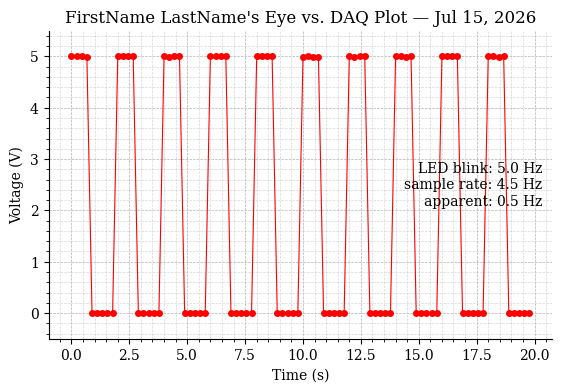

In [8]:
data = np.loadtxt('../Data/EyeVsDAQ_Capture.csv', delimiter=',', comments='#')
t_slow, v_slow = data[:, 0], data[:, 1]

f_led, fs_slow = 5.0, 4.5
f_app = abs(f_led - round(f_led / fs_slow) * fs_slow)

fig, ax = plt.subplots(figsize=(6.5, 4.0))
fig.patch.set_facecolor('white')

ax.plot(t_slow, v_slow, 'o-', color='red', markersize=4, linewidth=0.8)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Voltage (V)')
ax.set_ylim(-0.5, 5.5)
ax.set_title(f"FirstName LastName's Eye vs. DAQ Plot — {today}")
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.5)
ax.minorticks_on()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text(0.98, 0.5,
        f'LED blink: {f_led:.1f} Hz\nsample rate: {fs_slow:.1f} Hz\n'
        f'apparent: {f_app:.1f} Hz',
        transform=ax.transAxes, ha='right', va='center')

fig.savefig('../Figures/FirstName_LastName_Lab04_EyeVsDAQ.png',
            dpi=600, bbox_inches='tight')
fig.savefig('../Figures/FirstName_LastName_Lab04_EyeVsDAQ.pdf',
            dpi=600, bbox_inches='tight')
plt.show()

## Part-6 — flicker-fusion staircase (hardware path + synthetic results)

In [9]:
if ADS_CONNECTED:
    import dwfpy as dwf

    freqs_tested = []
    responses    = []       # 1 = flicker visible, 0 = looks steady

    with dwf.Device() as device:
        wavegen = device.analog_output

        f = 20.0                                 # start well below fusion
        while True:
            wavegen['ch1'].setup('square', frequency=f, amplitude=2.5,
                                 offset=2.5, start=True)
            answer = input(f"{f:.0f} Hz — do you see flicker? (y/n): ")

            freqs_tested.append(f)
            responses.append(1 if answer == 'y' else 0)

            if answer != 'y':
                break                            # fusion reached — stop
            f = f + 5                            # step up and ask again

    print(f"Flicker-fusion threshold: between {freqs_tested[-2]:.0f} "
          f"and {freqs_tested[-1]:.0f} Hz")

    np.savetxt('../Data/Flicker_Staircase_PartnerA.csv',   # rename per partner
               np.column_stack([freqs_tested, responses]),
               header='frequency_Hz,flicker_visible(1=yes 0=no)',
               delimiter=',', fmt='%d')

# Synthetic results: report each partner's threshold bracket
for name in ['PartnerA', 'PartnerB']:
    d = np.loadtxt(f'../Data/Flicker_Staircase_{name}.csv',
                   delimiter=',', comments='#')
    freqs, resp = d[:, 0], d[:, 1]
    last_yes  = freqs[resp == 1][-1]
    first_no  = freqs[resp == 0][0]
    print(f"{name}: flicker fusion between {last_yes:.0f} and {first_no:.0f} Hz")

PartnerA: flicker fusion between 55 and 60 Hz
PartnerB: flicker fusion between 65 and 70 Hz


## Grading / checking notes (TA)

**Part-3 (static comparison).**
- Expect DMM errors of a few mV, scattered (display resolution 1 mV
  dominates); ADS errors typically show a small *trend* with voltage (gain
  error) — worth pointing out if a student's plot shows it. Errors beyond
  ±50 mV suggest a wiring or range problem, not instrument error.
- Neither instrument is "truth": the W1 setpoint is the nominal reference.
  Students who note this in Q are thinking correctly.

**Part-4 (aliasing sweep).** Predicted apparent frequencies: 100 → 100 Hz,
450 → 450 Hz, 500 → boundary case (ambiguous; amplitude depends on phase),
550 → 450 Hz, 1125 → 125 Hz.
- Panels 2 and 4 should look *essentially identical* — that
  indistinguishability IS the point; ask students about it if they missed it.
- Panel 3 amplitude varies run-to-run (phase-dependent); any amplitude
  between 0 and 4 V pp is "correct". A flat line is also valid.
- Common errors: `round()` vs `np.floor()` in the folding formula; observed
  frequency read from peak *count* over the wrong window; mixing up f_N
  (500 Hz) with fs (1000 Hz).

**Part-5 (eye vs DAQ).** Apparent frequency must be ~0.5 Hz. If a student's
capture shows ~5 Hz, they sampled at 45 Hz (typo), not 4.5 Hz.

**Part-6 (flicker fusion).** Thresholds of 40–90 Hz are all physiologic;
outside that range suspect procedure (room lighting, peripheral vs central
viewing, or duty-cycle changes). No figure required — logbook data only.

**General.** Sign-flips are not possible in this lab (no differential
sensors), but swapped Ch1/W1 wiring shows up as a flat 0 V capture in
Part-4 — check the loopback tap first.